In [33]:
import pandas as pd

df = pd.read_csv("/vol/experiments2/cbrazier/transcription/datasets/ester1_ester2_epac/train/metadata.csv")
IPA_TO_SINGLE = {
    "dʒ": "dʒ","tʃ": "tʃ","ts": "ts","spn": "spn","a": "a","e": "e","i": "i","o": "o","u": "u","y": "y","ø": "ø","œ": "9","ə": "ə",
    "ɛ": "ɛ","ɔ": "ɔ","ɑ": "ɑ","ɑ̃": "@","ɔ̃": "§","ɛ̃": "5","œ̃": "1",
    "b": "b","d": "d","f": "f","k": "k","ɡ": "ɡ","p": "p","t": "t","v": "v","z": "z","s": "s",
    "m": "m","mʲ": "M","n": "n","ŋ": "ŋ","l": "l","ʎ": "ʎ","ʁ": "ʁ",
    "j": "j","w": "w","ɥ": "ɥ","ɲ": "ɲ","ʃ": "ʃ","ʒ": "ʒ","ɟ": "ɟ"
    
}

In [1]:

import json
with open('results/w2vCTC_FS_normalized_run2/checkpoint-8593/trainer_state.json') as f:
    state = json.load(f)

# Find checkpoint with highest sharpness
best = max(
    [l for l in state['log_history'] if 'eval/alignment_sharpness' in l],
    key=lambda x: x['eval/alignment_sharpness']
)
print(f\"Best sharpness: {best['eval/alignment_sharpness']:.2f}% at epoch {best['epoch']:.1f} step {best['step']}\")


SyntaxError: unexpected character after line continuation character (3803719092.py, line 10)

In [21]:
import os
os.environ["HF_HOME"] = "/vol/experiments/cache_imbenamor"
os.environ["HF_DATASETS_CACHE"] = "/vol/experiments/cache_imbenamor/datasets"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from dataclasses import dataclass
from datasets import load_dataset, load_from_disk, Audio
import json
import numpy as np
import torch
import torch.nn.functional as F
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    TrainingArguments,
    Trainer
)
from transformers.models.wav2vec2.modeling_wav2vec2 import Wav2Vec2ForCTC
from typing import Dict, List, Union
import editdistance

# =========================
# Config
# =========================
exp_name = "w2vCTC_VAD"
model_name = "/vol/experiments2/cbrazier/transcription/models/models--LeBenchmark--wav2vec2-FR-7K-large/snapshots/7fa1111246fca6eb198d1caab50fd2e4469bf659"
output_dir = f"results/{exp_name}"
os.makedirs(output_dir, exist_ok=True)
vocab_name = f"vocab_{exp_name}.json"
preprocessed_path = f"{output_dir}/preprocessed"
dataset = load_from_disk(preprocessed_path)
sample = dataset["train"][0]

print("RAW LABEL IDS:", sample["labels"])

decoded = processor.tokenizer.decode(
    [i for i in sample["labels"] if i not in [-100, processor.tokenizer.pad_token_id]]
)

print("DECODED:", decoded)

RAW LABEL IDS: [20, 7, 22, 38, 13, 21, 14, 7, 17, 7, 38, 22, 4, 15, 34, 26, 27, 7, 21, 13, 15, 34, 26, 27, 7, 16, 7]
DECODED: patʁisjamaʁt5kəvwasikəvwala


In [ ]:
import json



with open("results.json") as f:
    for line in f:
        data = json.loads(line)
        if data["PER"] < best_per:
            best_per = data["PER"]
            best_ckpt = data["checkpoint"]

print(best_ckpt, best_per)

In [14]:


import json

results = []
best_per = float("inf")
best_ckpt = None
with open("results/w2vCTC/eval_results.json", "r") as f:
    text=f.readlines()
raw = ''.join(text)
raw = raw.replace('}{', '}\n{')

clean_data = []
for line in raw.splitlines():
    line = line.strip()
    if not line:
        continue
    try:
        clean_data.append(json.loads(line))
    except json.JSONDecodeError:
        pass  # skip bad lines
for data in clean_data:
    if data["PER"] < best_per:
            best_per = data["PER"]
            best_ckpt = data["checkpoint"]

print(best_ckpt, best_per)

results/w2vCTC/checkpoint-22656 0.03532354614681946


In [6]:
per_test_ctc=[]
for line in clean_data:
    per_test_ctc.append(line["PER"])

In [17]:
import json
import matplotlib.pyplot as plt
results = []
best_per = float("inf")
best_ckpt = None
with open("results/w2vCTC_VAD_SIL/eval_results.json", "r") as f:
    for line in f:
        results.append(json.loads(line))
for data in results:
    if data["PER"] < best_per:
            best_per = data["PER"]
            best_ckpt = data["checkpoint"]

print(best_ckpt, best_per)
per_test_ctc_vad_sil=[]
for line in results:
    per_test_ctc_vad_sil.append(line["PER"])


results/w2vCTC_VAD_SIL/checkpoint-23430 0.0455600465063312


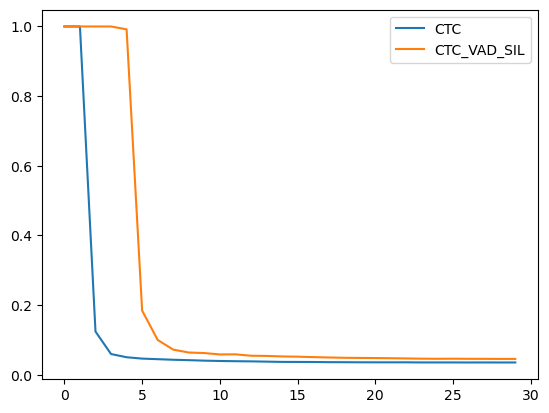

In [18]:
plt.plot(per_test_ctc,label="CTC")
plt.plot(per_test_ctc_vad_sil,label="CTC_VAD_SIL")
plt.legend()

In [5]:
from datasets import load_from_disk
import numpy as np
dataset_path = "results/w2vCTC_VAD_SIL/preprocessed"
dataset = load_from_disk(dataset_path)["test"]
sample = dataset[32]
audio = np.array(sample["input_values"])
sr = 16000

time = np.arange(len(audio)) / sr

/home/imbenamor/miniconda3/envs/venv-test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
import os
os.environ["HF_HOME"] = "/vol/experiments/cache_imbenamor"
os.environ["HF_DATASETS_CACHE"] = "/vol/experiments/cache_imbenamor/datasets"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from dataclasses import dataclass
from datasets import load_dataset, load_from_disk, Audio
import json
import numpy as np
import torch
import torch.nn.functional as F
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    TrainingArguments,
    Trainer
)
from transformers.models.wav2vec2.modeling_wav2vec2 import Wav2Vec2ForCTC
from typing import Dict, List, Union
import editdistance
device = "cuda"
exp_name = "w2vCTC_VAD"
model_name = "/vol/experiments2/cbrazier/transcription/models/models--LeBenchmark--wav2vec2-FR-7K-large/snapshots/7fa1111246fca6eb198d1caab50fd2e4469bf659"
output_dir = f"results/{exp_name}"
os.makedirs(output_dir, exist_ok=True)
vocab_name = f"vocab_{exp_name}.json"
preprocessed_path = f"{output_dir}/preprocessed"
dataset = load_from_disk(preprocessed_path)
# =========================
# Processor reload
# =========================
tokenizer = Wav2Vec2CTCTokenizer(
    vocab_file=vocab_name,
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token=""
)

feature_extractor = Wav2Vec2FeatureExtractor(
    sampling_rate=16000,
    return_attention_mask=False
)

processor = Wav2Vec2Processor(
    feature_extractor=feature_extractor,
    tokenizer=tokenizer
)

sil_id = tokenizer.convert_tokens_to_ids("SIL")

# =========================
# Data collator
# =========================
@dataclass
class DataCollatorCTCWithPadding:
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        # VAD padding
        vad = [torch.tensor(f["vad"]) for f in features]
        vad = torch.nn.utils.rnn.pad_sequence(vad, batch_first=True)

        batch["labels"] = labels
        batch["vad"] = vad

        return batch

data_collator = DataCollatorCTCWithPadding(processor=processor)
class Wav2Vec2ForCTCWithVAD(Wav2Vec2ForCTC):

    def apply_vad_bias(self, logits, vad):
        vad = F.interpolate(vad.unsqueeze(1), size=logits.shape[1], mode="nearest").squeeze(1)
        vad = vad.clamp(1e-4, 1 - 1e-4)

        V = logits.shape[-1]

        sil_mask = torch.zeros(V, device=logits.device)
        sil_mask[self.config.sil_token_id] = 1.0
        sil_mask = sil_mask.view(1, 1, V)

        phoneme_mask = 1 - sil_mask
        vad = vad.unsqueeze(-1)

        logits = logits + (
            sil_mask * torch.log(1 - vad) +
            phoneme_mask * torch.log(vad)
        )
        return logits

    def forward(self, input_values, vad=None):
        outputs = self.wav2vec2(input_values)
        logits = self.lm_head(outputs.last_hidden_state)

        if vad is not None:
            logits = self.apply_vad_bias(logits, vad)

        return {"logits": logits}


# =========================
# Viterbi alignment
# =========================
def build_eY(tokens, sil_token="SIL"):
    eY = [sil_token]
    for t in tokens:
        eY.append(t)
        eY.append(sil_token)
    return eY


def viterbi_align(log_probs, eY_ids):
    T, V = log_probs.shape
    L = len(eY_ids)

    A = torch.full((T, L), -1e9, device=log_probs.device)
    B = torch.zeros((T, L), dtype=torch.long, device=log_probs.device)

    A[0, 0] = log_probs[0, eY_ids[0]]

    for t in range(1, T):
        for j in range(L):
            candidates = []

            # stay
            candidates.append((A[t-1, j], j))

            # j-1
            if j > 0:
                candidates.append((A[t-1, j-1], j-1))

            # j-2
            if j > 1 and eY_ids[j] != eY_ids[j-2]:
                candidates.append((A[t-1, j-2], j-2))

            best_score, best_state = max(candidates, key=lambda x: x[0])

            A[t, j] = best_score + log_probs[t, eY_ids[j]]
            B[t, j] = best_state

    # backtrack
    path = []
    j = L - 1
    for t in reversed(range(T)):
        path.append(eY_ids[j])
        j = B[t, j]

    return list(reversed(path))

# ========================= 
# Extract timestamps 
# ========================= 
def extract_segments(path_ids, tokenizer, frame_duration=0.02): 
    tokens = [tokenizer.convert_ids_to_tokens(i) for i in path_ids] 
    segments = [] 
    current = tokens[0] 
    start = 0 
    for i, t in enumerate(tokens): 
        if t != current: 
            segments.append({ "token": current, "start": start * frame_duration, "end": i * frame_duration })
            current = t 
            start = i 
    segments.append({ "token": current, "start": start * frame_duration, "end": len(tokens) * frame_duration }) 
    return segments

#adaptive VAD threshold
def compute_adaptive_threshold(vad, percentile=20):
    thr = np.percentile(vad, percentile)
    return max(0.02, min(thr, 0.3))  # clamp for stability
def filter_sil_with_vad(segments, vad, frame_duration=0.02, threshold=0.1):
    filtered = []

    for seg in segments:
        if seg["token"] != "SIL":
            filtered.append(seg)
            continue

        start_f = int(seg["start"] / frame_duration)
        end_f = int(seg["end"] / frame_duration)

        vad_segment = vad[start_f:end_f]
        if len(vad_segment) == 0:
            continue

        # 🔥 robust rule
        silence_ratio = (vad_segment < threshold).mean()

        if silence_ratio > 0.2 and (seg["end"] - seg["start"]) > 0.04:
            filtered.append(seg)

    return filtered

def merge_segments(segments):
    merged = []
    for seg in segments:
        if not merged:
            merged.append(seg)
            continue

        last = merged[-1]

        if seg["token"] == last["token"]:
            last["end"] = max(last["end"], seg["end"])
        else:
            merged.append(seg)

    return merged
def refine_sil_segments(segments, vad, frame_duration=0.02, threshold=0.1):
    refined = []

    for seg in segments:
        if seg["token"] != "SIL":
            refined.append(seg)
            continue

        start_f = int(seg["start"] / frame_duration)
        end_f = int(seg["end"] / frame_duration)

        # move start forward (remove speech frames)
        while start_f < end_f and vad[start_f] >= threshold:
            start_f += 1

        # move end backward (remove speech frames)
        while end_f > start_f and vad[end_f - 1] >= threshold:
            end_f -= 1

        # keep only if still valid
        if end_f > start_f:
            refined.append({
                "token": "SIL",
                "start": start_f * frame_duration,
                "end": end_f * frame_duration
            })

    return refined
def fill_gaps_with_neighbors(segments):
    filled = []

    for i in range(len(segments)):
        filled.append(segments[i])

        if i < len(segments) - 1:
            gap_start = segments[i]["end"]
            gap_end = segments[i+1]["start"]

            if gap_end > gap_start:
                # attach gap to previous phoneme
                filled[-1]["end"] = gap_end

    return filled
def compute_vad_energy(audio, frame_size=320, hop_size=320):
    audio = np.array(audio)

    energy = []
    for i in range(0, len(audio) - frame_size, hop_size):
        frame = audio[i:i+frame_size]
        e = np.mean(frame ** 2)
        energy.append(e)

    energy = np.array(energy)
    energy = energy / (energy.max() + 1e-8)

    return energy  # continuous VAD
input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to(device)

model = Wav2Vec2ForCTCWithVAD.from_pretrained(
    model_name,
    vocab_size=len(tokenizer),
    pad_token_id=tokenizer.pad_token_id,
)

model.config.sil_token_id = sil_id
model.freeze_feature_encoder()

# ===== Compute VAD =====

audio = sample["input_values"]
vad_np = compute_vad_energy(audio)

# ===== Adaptive threshold =====
threshold = compute_adaptive_threshold(vad_np, percentile=20)
print("Threshold:", threshold)

vad = torch.tensor(vad_np).unsqueeze(0).to(device)

# ===== Forward =====
with torch.no_grad():
    logits = model(input_values, vad=vad)["logits"][0]

log_probs = torch.log_softmax(logits, dim=-1)

# ===== Decode tokens =====
pred_ids = torch.argmax(logits, dim=-1)

pred_tokens = [
    tokenizer.convert_ids_to_tokens(int(i))
    for i in pred_ids
]

# CTC collapse
def ctc_collapse(tokens):
    out = []
    prev = None
    for t in tokens:
        if t != prev and t != "[PAD]":
            out.append(t)
        prev = t
    return out

pred_tokens = ctc_collapse(pred_tokens)
pred_tokens = [t for t in pred_tokens if t not in ["[PAD]", "[UNK]"]]

# ===== Viterbi =====
eY = build_eY(pred_tokens)
eY_ids = [tokenizer.convert_tokens_to_ids(t) for t in eY]

aligned_ids = viterbi_align(log_probs, eY_ids)
segments = extract_segments(aligned_ids, tokenizer)
# ===== Filter SIL using VAD =====
segments = filter_sil_with_vad(
    segments,
    vad_np,
    frame_duration=0.02,
    threshold=threshold
)

# ===== merge =====
segments = merge_segments(segments)

# ===== fill gaps =====
segments = fill_gaps_with_neighbors(segments)
segments = refine_sil_segments(
    segments,
    vad_np,
    frame_duration=0.02,
    threshold=threshold
)
# ===== OUTPUT =====
for seg in segments:
    print(seg)



Some weights of Wav2Vec2ForCTCWithVAD were not initialized from the model checkpoint at /vol/experiments2/cbrazier/transcription/models/models--LeBenchmark--wav2vec2-FR-7K-large/snapshots/7fa1111246fca6eb198d1caab50fd2e4469bf659 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'lm_head.bias', 'lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Threshold: 0.023107412389971667


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

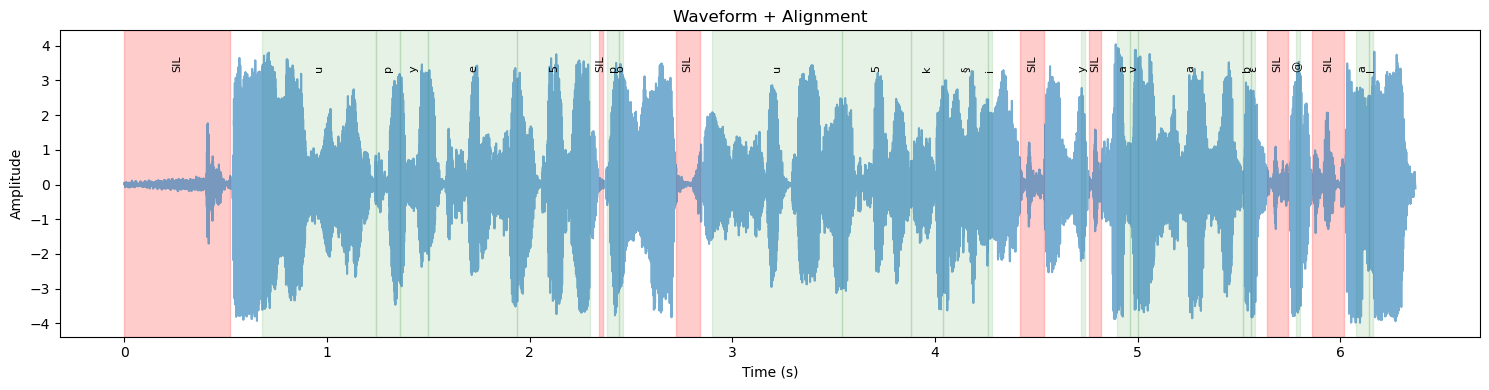

In [49]:
plt.figure(figsize=(15, 4))
plt.plot(time, audio, alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform + Alignment")
for seg in segments:
    start = seg["start"]
    end = seg["end"]
    token = seg["token"]

    # color SIL differently
    if token == "SIL":
        color = "red"
        alpha = 0.2
    else:
        color = "green"
        alpha = 0.1

    plt.axvspan(start, end, color=color, alpha=alpha)

    # label (center of segment)
    mid = (start + end) / 2
    plt.text(mid, 0.8 * np.max(audio), token,
             ha="center", va="bottom", fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

In [50]:
!pip install pyannote.audio
!pip install torch torchaudio

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Using cached torch-2.4.1-cp38-cp38-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached triton-3.0.0-1-cp38-cp38-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.7/898.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 63.3 MB/s eta 0:00:00
Using cached torch-2.4.1-cp38-cp38-manylinux1_x86_64.whl (797.1 MB)
Using cached triton-3.0.0-1-cp38-cp38-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (209.4 MB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13705 sha256=b7f8a86b5dc6ae79064504913eba6501d9c1b10a259f80e49afa8261d6490a75
  Stored in directory: /home/imbenamor/.cache/pip/wheels/56/ea/58/ead137b087d9e326852a851351d1debf4ada529b6ac0ec4e8c
  Created w

In [34]:
phonemes_single = []

for seq in df["phonemes"]:
    tokens = []

    for word in seq.split():
        for p in word.split("|"):
            if p.strip() == "":
                continue
            tokens.append(IPA_TO_SINGLE.get(p, p))

    phonemes_single.append(" ".join(tokens))

df["phoneme_single_v1"]=phonemes_single
def merge_phonemes(seq):
    tokens = seq.split()
    merged = []
    i = 0

    while i < len(tokens):
        # Look ahead for merge patterns
        if i < len(tokens) - 1:
            pair = tokens[i] + tokens[i+1]

            if pair in {"dʒ", "tʃ", "ts"}:
                merged.append(pair)
                i += 2
                continue

        # otherwise keep single token
        merged.append(tokens[i])
        i += 1

    return " ".join(merged)
df["phoneme_single_v1"] = df["phoneme_single_v1"].apply(merge_phonemes)

In [35]:
df[["file_name","transcription","phonemes","phonemes_single","phoneme_single_v1"]].to_csv("/vol/experiments2/cbrazier/transcription/datasets/ester1_ester2_epac/train/metadata.csv")